In [11]:
import requests
import re
import os


url = 'https://dicom.offis.de/download/images/ddsm/'
output_folder = "/home/hassan/dicom/data"


r = requests.get(url)
var = r.text
expected_start = '<a href="'
expected_end = '">'
result = re.findall(rf"{expected_start}(?![\?/])(.*?){expected_end}", var)

In [12]:
from pathlib import Path
for item in result:
    file_path = os.path.join(output_folder, item)
    if Path(file_path).is_file():
        print('exists, *skips*')
        continue
    else:
        print('doesnt, downloading')
        response = requests.get(url+item, stream=True)
        response.raise_for_status()
        with open(file_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        
        print('done')

exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
doesnt, downloading
done
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*
exists, *skips*

In [ ]:
import zipfile
import pandas as pd
from pydicom import dcmread
import numpy as np
import cv2
import re
import os

source_dir = r'/home/hassan/dicom/data/'
unzip_dir = r'/home/hassan/dicom/unzipped/'
label_pattern = r"^(.*?)(?=_\d|$)"
period_pattern =  r"\.([^.]+)\."

In [ ]:
#Extracting
for item in os.listdir(source_dir):
    if item.endswith(".zip"):
        file_name = source_dir + item
        zip_ref = zipfile.ZipFile(file_name)
        zip_ref.extractall(unzip_dir)


        zip_ref.close()
        


in here
normals_13.zip
in here
cancers_06.zip
in here
benigns_04.zip
in here
benigns_02.zip
in here
cancers_21.zip
in here
cancers_11.zip
in here
benigns_19.zip
in here
benigns_03.zip
in here
cancers_05.zip
in here
normals_01.zip
in here
benigns_20.zip
in here
normals_08.zip
in here
normals_04.zip
in here
cancers_03.zip
in here
benign_without_callbacks_2.zip
in here
benigns_01.zip
in here
normals_15.zip
in here
cancers_02.zip
in here
normals_11.zip
in here
normals_16.zip
in here
cancers_13.zip
in here
benign_without_callbacks_3.zip
in here
benigns_07.zip
in here
benigns_16.zip
in here
benigns_14.zip
in here
cancers_10.zip
in here
README
in here
benigns_11.zip
in here
normals_06.zip
in here
cancers_07.zip
in here
normals_03.zip
in here
normals_10.zip
in here
benigns_18.zip
in here
normals_09.zip
in here
cancers_18.zip
in here
normals_12.zip
in here
cancers_17.zip
in here
cancers_12.zip
in here
cancers_01.zip
in here
cancers_14.zip
in here
benign_without_callbacks_1.zip
in here
benigns_1

In [ ]:
#Processing

records = []
prefix = 'processed_'
new_width = 512
new_height = 512

base_unzip = Path(unzip_dir)

for label in base_unzip.iterdir():
    if not label.is_dir():
        continue

    for patient_dir in label.iterdir():
        if not patient_dir.is_dir():
            continue
        output_folder_name = label / f"{prefix}{patient_dir.name}"
        output_folder_name.mkdir(parents=True, exist_ok=True)
        print(patient_dir.name + ' done')
        for dcm in patient_dir.iterdir():
            if not dcm.name.endswith(".dcm"):
                continue

            view_type = re.search(period_pattern, dcm.name).group(1)

            output_fn = output_folder_name / f"{view_type}.png"
            
            
            ds = dcmread(dcm)
            arr = ds.pixel_array
            arr_uint8= cv2.normalize(arr, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
            # arr_normalized = arr_uint8.astype(np.float32) / 255.0
            resized = cv2.resize(arr_uint8, (new_width, new_height))

            cv2.imwrite(str(output_fn), resized)
            
            records.append({
                'patient_id': patient_dir.name,
                'file_path': str(output_fn),
                'label': label.name,
                'view_type': view_type,
            })

central = pd.DataFrame(records)
central.to_csv('central.csv', index =False)


patient8479 done
patient7979 done
patient2596 done
patient6169 done
patient1679 done
patient8996 done
patient1479 done
patient7899 done
patient3169 done
patient4999 done
patient7696 done
patient2096 done
patient5679 done
patient4996 done
patient2969 done
patient9269 done
patient1896 done
patient9579 done
patient3799 done
patient1169 done
patient0899 done
patient7579 done
patient0269 done
patient5696 done
patient5879 done
patient2269 done
patient3069 done
patient4269 done
patient6779 done
patient9169 done
patient0779 done
patient9896 done
patient5779 done
patient6096 done
patient5096 done
patient4579 done
patient7069 done
patient0699 done
patient9899 done
patient4369 done
patient0896 done
patient8579 done
patient4169 done
patient7896 done
patient3269 done
patient1696 done
patient5579 done
patient2169 done
patient4796 done
patient8899 done
patient2896 done
patient5899 done
patient2779 done
patient2996 done
patient3096 done
patient4779 done
patient9696 done
patient5069 done
patient6879 do

AttributeError: 'DataFrame' object has no attribute 'csv'

In [2]:
import pandas as pd
central = pd.read_csv('central.csv')

In [ ]:
import torch
import torchvision.transforms.v2 as T
#**NOTE: Vertical flips, not gonna. Incorrect anatomy might mess up pretrained models learned weights? unconmfirmed, but asummed to be the case.** 
train_transforms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True), #scaling to float (0.0-1.0)
    #horizontal flip
    T.RandomHorizontalFlip(p=0.5),

    #slight rotation and zoom in/out
    T.RandomAffine(degrees = 10, scale=(0.9, 1.1)),

    T.ColorJitter(brightness = 0.2, contrast = 0.2),

    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) #or normalize with ddsm statistics?

])
val_transform = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [4]:
import torch
from torch.utils.data import Dataset
from PIL import Image


class MammographyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        
        # Map string labels to numbers (0, 1, 2, 3)
        self.label_mapping = {
            'normals': 0,
            'benigns': 1,
            'benign_without_callbacks': 1, # Often merged with benigns
            'cancers': 2
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # 1. Read the preprocessed PNG
        image_path = row['file_path']
        image = Image.open(image_path).convert('RGB') # Load as PIL Image
        
        # 2. Get target label
        label_str = row['label']
        label_tensor = torch.tensor(self.label_mapping[label_str], dtype=torch.long)
        
        # 3. Apply augmentation transforms (on the fly)
        if self.transform:
            image = self.transform(image)
            
        return image, label_tensor

In [ ]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
#grouped split since spreading without grouped shuffle could promote validation overfitting to the training
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, temp_idx = next(gss1.split(central, groups=central['patient_id']))

train_df = central.iloc[train_idx]
val_df = central.iloc[temp_idx]

In [ ]:
from torch.utils.data import DataLoader

train_dataset = MammographyDataset(df=train_df, transform=train_transforms)
val_dataset = MammographyDataset(df=val_df, transform=val_transform)

# 16/1w
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=1)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=1)

In [ ]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

# dl resnet50 with pretrianed weights
model = resnet50(weights=ResNet50_Weights.DEFAULT)

In [ ]:
# Replacing the final layer with a one that outputs 3 classes
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)    

In [ ]:
import torch.optim as optim

# MCC defaults
criterion = nn.CrossEntropyLoss()

#alts adamW, adamw_8bit
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
import torch

num_epochs = 10 

best_val_loss = float('inf') 

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 10)
    
    #train
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    
    for images, labels in train_loader:
        
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad() # zeroing the parameter gradient to clear last batch gradients so they don't accumulate before 

        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        #calc graidents and update weights
        loss.backward()
        optimizer.step()
        
        # Track statistics
        running_loss += loss.item() * images.size(0)
        _, predictions = torch.max(outputs, 1)
        correct_preds += (predictions == labels).sum().item()
        total_preds += labels.size(0)
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct_preds / total_preds
    
    #val
    model.eval()  # Sets the model to evaluation mode
    val_running_loss = 0.0
    val_correct_preds = 0
    val_total_preds = 0
    
    # dont need gradient for val, so no grad to save mem
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_running_loss += loss.item() * images.size(0)
            _, predictions = torch.max(outputs, 1)
            val_correct_preds += (predictions == labels).sum().item()
            val_total_preds += labels.size(0)
            
    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    epoch_val_acc = val_correct_preds / val_total_preds
    
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}\n")
    
    #save best model
    if epoch_val_loss < best_val_loss:
        print(f"Validation loss improved ({best_val_loss:.4f} -> {epoch_val_loss:.4f}). Saving model...")
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), 'best_resnet50_mammography.pth')

print("Training Complete!")

Epoch 1/10
----------


In [130]:
import numpy as np
from pydicom import dcmread
import matplotlib.pyplot as plt
import cv2

path = r"/home/hassan/dicom/patient0169/0169.LEFT_CC.dcm"
ds = dcmread(path)
arr = ds.pixel_array
arr_uint8= cv2.normalize(arr, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
arr_normalized = arr_uint8.astype(np.float32) / 255.0
plt.imshow(arr, cmap="gray")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/hassan/dicom/patient0169/0169.LEFT_CC.dcm'

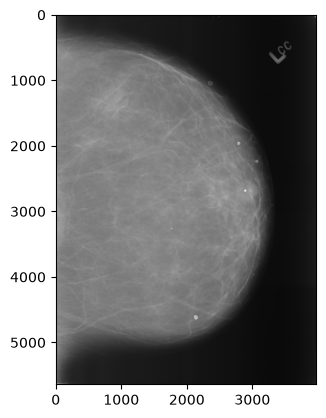

In [27]:
plt.imshow(arr, cmap="gray")
plt.show()

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt

2026-07-29 12:16:53.225102: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-29 12:16:53.243054: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785316613.264358    9271 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785316613.269435    9271 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785316613.282299    9271 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 